## Importing necessary libraries and setting consistent theme for visualization

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Set a consistent theme for visualizations
sns.set_theme(style="whitegrid", palette="viridis")

print("Libraries imported and seaborn theme set.")

Libraries imported and seaborn theme set.


### Loading the dataset

In [40]:
from google.colab import drive
drive.mount('/content/drive')

try:
    df = pd.read_csv('/content/drive/MyDrive/AirBNB analytics/airbnb_cleaned.csv')
    print("Google Drive mounted and dataset loaded")
    display(df.head())
except FileNotFoundError:
    print("File not found. Please ensure the path to your file in Google Drive is correct.")
except Exception as e:
    print(f"An error occurred: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted and dataset loaded


,name,host_name,host_since,host_response_time,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,neighbourhood,neighbourhood_cleansed,...,number_of_reviews,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,cancellation_policy,has_reviews
0,Stylish Queen Anne Apartment,Maija,2011-08-11,within a few hours,False,Queen Anne,3.0,3.0,Queen Anne,West Queen Anne,...,207,10.0,10.0,10.0,10.0,9.0,10.0,False,moderate,1
1,Bright & Airy Queen Anne Apartment,Andrea,2013-02-21,within an hour,True,Queen Anne,6.0,6.0,Queen Anne,West Queen Anne,...,43,10.0,10.0,10.0,10.0,10.0,10.0,False,strict,1
2,New Modern House-Amazing water view,Jill,2014-06-12,within a few hours,False,Queen Anne,2.0,2.0,Queen Anne,West Queen Anne,...,20,10.0,10.0,10.0,10.0,10.0,10.0,False,strict,1
3,Queen Anne Chateau,Emily,2013-11-06,unknown,False,Queen Anne,1.0,1.0,Queen Anne,West Queen Anne,...,0,10.0,10.0,10.0,10.0,10.0,10.0,False,flexible,0
4,Charming craftsman 3 bdm house,Emily,2011-11-29,within an hour,False,Queen Anne,2.0,2.0,Queen Anne,West Queen Anne,...,38,9.0,9.0,10.0,10.0,9.0,9.0,False,strict,1


In [41]:
df.head()

,name,host_name,host_since,host_response_time,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,neighbourhood,neighbourhood_cleansed,...,number_of_reviews,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,cancellation_policy,has_reviews
0,Stylish Queen Anne Apartment,Maija,2011-08-11,within a few hours,False,Queen Anne,3.0,3.0,Queen Anne,West Queen Anne,...,207,10.0,10.0,10.0,10.0,9.0,10.0,False,moderate,1
1,Bright & Airy Queen Anne Apartment,Andrea,2013-02-21,within an hour,True,Queen Anne,6.0,6.0,Queen Anne,West Queen Anne,...,43,10.0,10.0,10.0,10.0,10.0,10.0,False,strict,1
2,New Modern House-Amazing water view,Jill,2014-06-12,within a few hours,False,Queen Anne,2.0,2.0,Queen Anne,West Queen Anne,...,20,10.0,10.0,10.0,10.0,10.0,10.0,False,strict,1
3,Queen Anne Chateau,Emily,2013-11-06,unknown,False,Queen Anne,1.0,1.0,Queen Anne,West Queen Anne,...,0,10.0,10.0,10.0,10.0,10.0,10.0,False,flexible,0
4,Charming craftsman 3 bdm house,Emily,2011-11-29,within an hour,False,Queen Anne,2.0,2.0,Queen Anne,West Queen Anne,...,38,9.0,9.0,10.0,10.0,9.0,9.0,False,strict,1


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3726 entries, 0 to 3725
Data columns (total 42 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   name                          3726 non-null   object 
 1   host_name                     3726 non-null   object 
 2   host_since                    3726 non-null   object 
 3   host_response_time            3726 non-null   object 
 4   host_is_superhost             3726 non-null   bool   
 5   host_neighbourhood            3726 non-null   object 
 6   host_listings_count           3724 non-null   float64
 7   host_total_listings_count     3724 non-null   float64
 8   neighbourhood                 3726 non-null   object 
 9   neighbourhood_cleansed        3726 non-null   object 
 10  neighbourhood_group_cleansed  3726 non-null   object 
 11  latitude                      3726 non-null   float64
 12  longitude                     3726 non-null   float64
 13  is_

In [43]:
df.shape

(3726, 42)

### Descriptive statistics

In [44]:
df.describe()

,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,guests_included,bathrooms,bedrooms,beds,price,...,availability_90,availability_365,number_of_reviews,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,has_reviews
count,3724.000000,3724.000000,3726.000000,3726.000000,3726.000000,3726.000000,3726.000000,3726.000000,3726.000000,3726.000000,...,3726.000000,3726.000000,3726.000000,3726.000000,3726.000000,3726.000000,3726.000000,3726.000000,3726.000000,3726.000000
mean,7.284372,7.284372,47.629029,-122.333090,3.346216,1.698604,1.259796,1.315352,1.745035,128.473430,...,58.061728,244.812668,22.133655,9.699410,9.633119,9.821524,9.841385,9.675523,9.546430,0.828234
std,28.967077,28.967077,0.042966,0.031757,1.893357,1.215397,0.592349,0.884234,1.146431,90.543974,...,34.136763,126.845463,37.935061,0.650315,0.747160,0.552314,0.526163,0.593184,0.716717,0.377228
min,1.000000,1.000000,47.505088,-122.417219,1.000000,1.000000,0.000000,0.000000,1.000000,20.000000,...,0.000000,0.000000,0.000000,2.000000,3.000000,2.000000,2.000000,4.000000,2.000000,0.000000
25%,1.000000,1.000000,47.609461,-122.354215,2.000000,1.000000,1.000000,1.000000,1.000000,75.000000,...,28.000000,124.000000,2.000000,10.000000,9.000000,10.000000,10.000000,9.000000,9.000000,1.000000
50%,1.000000,1.000000,47.623688,-122.328898,3.000000,1.000000,1.000000,1.000000,1.000000,100.000000,...,74.000000,308.000000,9.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,1.000000
75%,3.000000,3.000000,47.662671,-122.310745,4.000000,2.000000,1.000000,2.000000,2.000000,150.000000,...,89.000000,360.000000,26.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,1.000000
max,502.000000,502.000000,47.733358,-122.240607,10.000000,7.000000,8.000000,7.000000,15.000000,1000.000000,...,90.000000,365.000000,474.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,1.000000


## Univariate Analysis

Numerical Features

Col = price

In [45]:
df['price'].skew()

np.float64(3.1101292802360145)

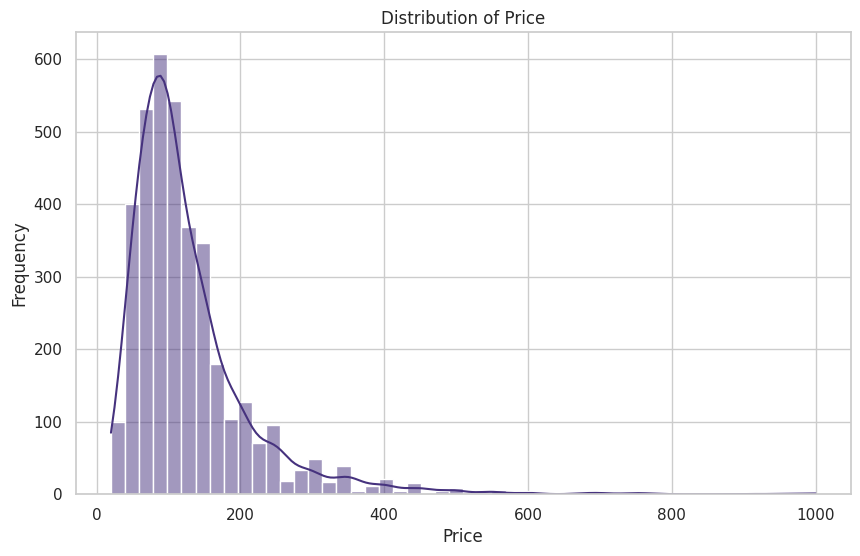

In [46]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribution of Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

####  Sharp right skew —  more than 70% of listings sit under $150 per night, with a long tail out to $1000

Col = accommodates

In [47]:
df['accommodates'].skew()

np.float64(1.2726159612183987)

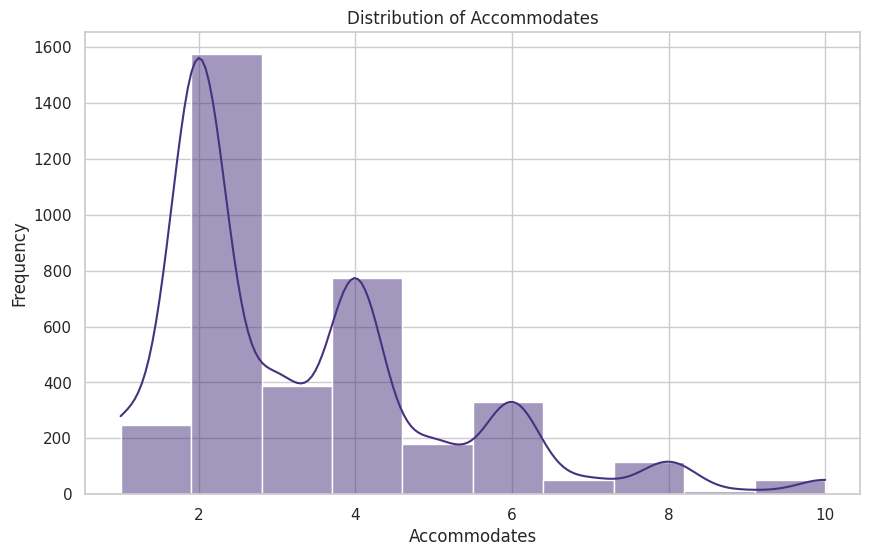

In [48]:
plt.figure(figsize=(10, 6))
sns.histplot(df['accommodates'], bins=len(df['accommodates'].unique()), kde=True)
plt.title('Distribution of Accommodates')
plt.xlabel('Accommodates')
plt.ylabel('Frequency')
plt.show()

Col = minimum_nights

In [49]:
df['minimum_nights'].skew()

np.float64(4.013785484490052)

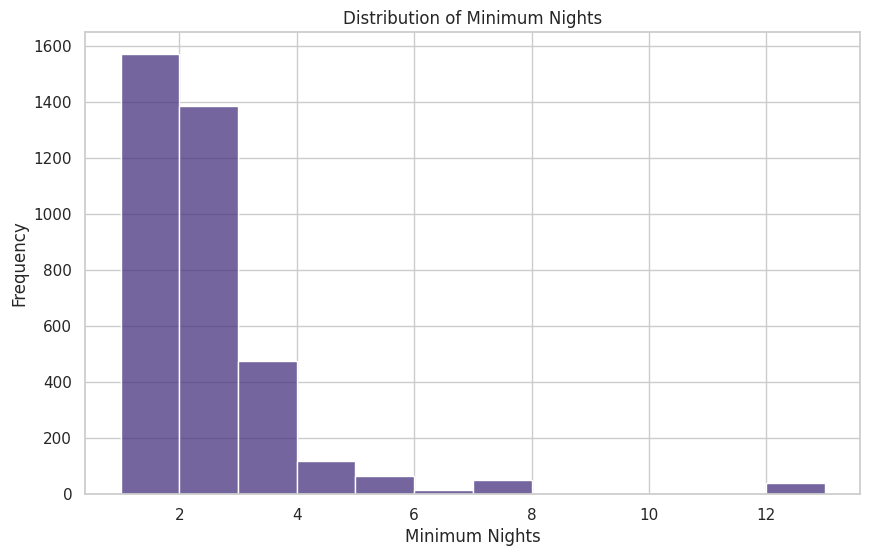

In [50]:
plt.figure(figsize=(10, 6))
sns.histplot(df['minimum_nights'], bins=len(df['minimum_nights'].unique()))
plt.title('Distribution of Minimum Nights')
plt.xlabel('Minimum Nights')
plt.ylabel('Frequency')
plt.show()

Col = number_of_reviews

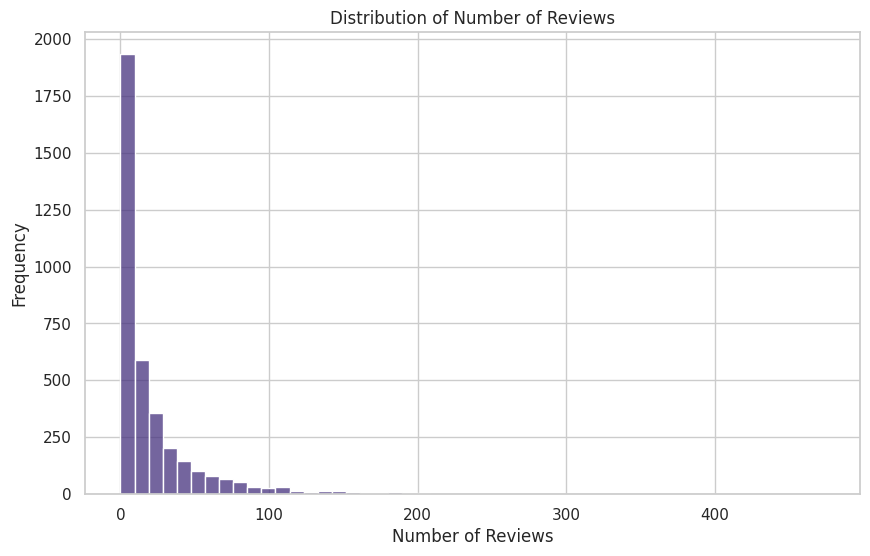

In [51]:
plt.figure(figsize=(10, 6))
sns.histplot(df['number_of_reviews'], bins=50)
plt.title('Distribution of Number of Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Frequency')
plt.show()

Col = availability_30

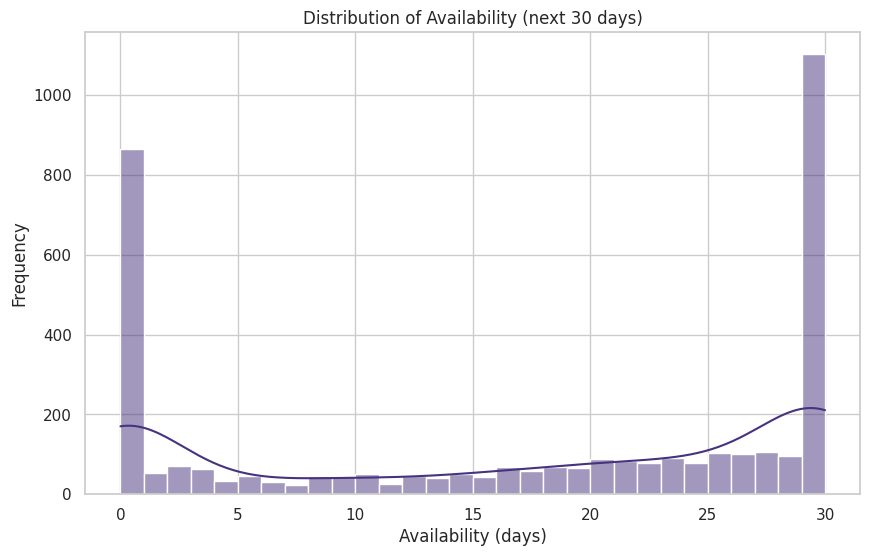

In [52]:
plt.figure(figsize=(10, 6))
sns.histplot(df['availability_30'], bins=30, kde=True)
plt.title('Distribution of Availability (next 30 days)')
plt.xlabel('Availability (days)')
plt.ylabel('Frequency')
plt.show()

Col = availability_60

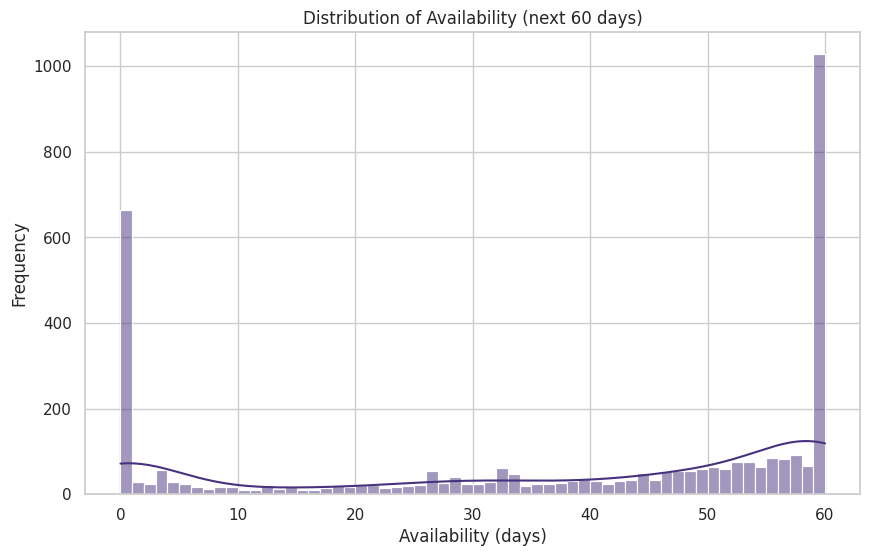

In [53]:
plt.figure(figsize=(10, 6))
sns.histplot(df['availability_60'], bins=60, kde=True)
plt.title('Distribution of Availability (next 60 days)')
plt.xlabel('Availability (days)')
plt.ylabel('Frequency')
plt.show()

Categorical Features

col = host_is_superhost

In [54]:
df['host_is_superhost'].value_counts()

,count
host_is_superhost,
False,2966
True,760


Col = is_location_exact

In [55]:
df['is_location_exact'].value_counts()

,count
is_location_exact,
True,3343
False,383


Col = instant_bookable

In [56]:
df['instant_bookable'].value_counts()

,count
instant_bookable,
False,3162
True,564


Col = cancellation_policy

In [57]:
df['cancellation_policy'].value_counts()

,count
cancellation_policy,
strict,1388
moderate,1215
flexible,1123


Col = has_reviews

In [58]:
df['has_reviews'].value_counts()

,count
has_reviews,
1,3086
0,640


Col = property_type

In [59]:
df['property_type'].value_counts()

,count
property_type,
House,1697
Apartment,1656
Townhouse,117
Condominium,89
Loft,39
Bed & Breakfast,37
Other,22
Cabin,21
Camper/RV,13


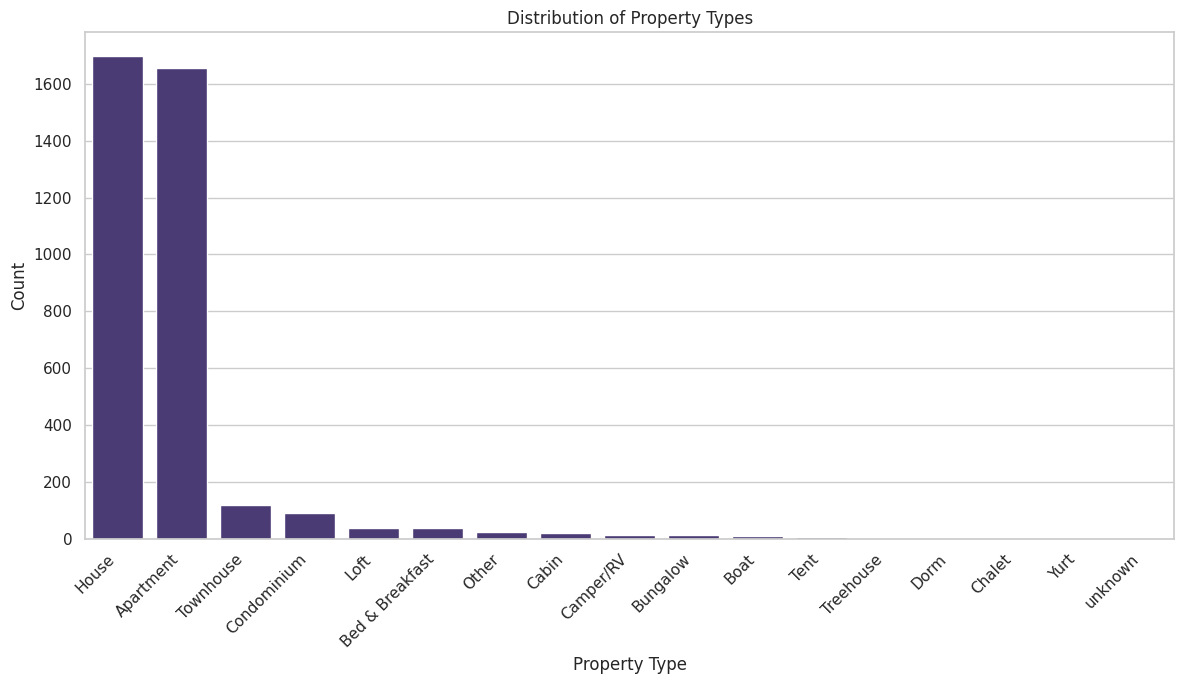

In [60]:
plt.figure(figsize=(12, 7))
sns.countplot(data=df, x='property_type', order = df['property_type'].value_counts().index)
plt.title('Distribution of Property Types')
plt.xlabel('Property Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Col = room_type

In [61]:
df['room_type'].value_counts()

,count
room_type,
Entire home/apt,2482
Private room,1131
Shared room,113


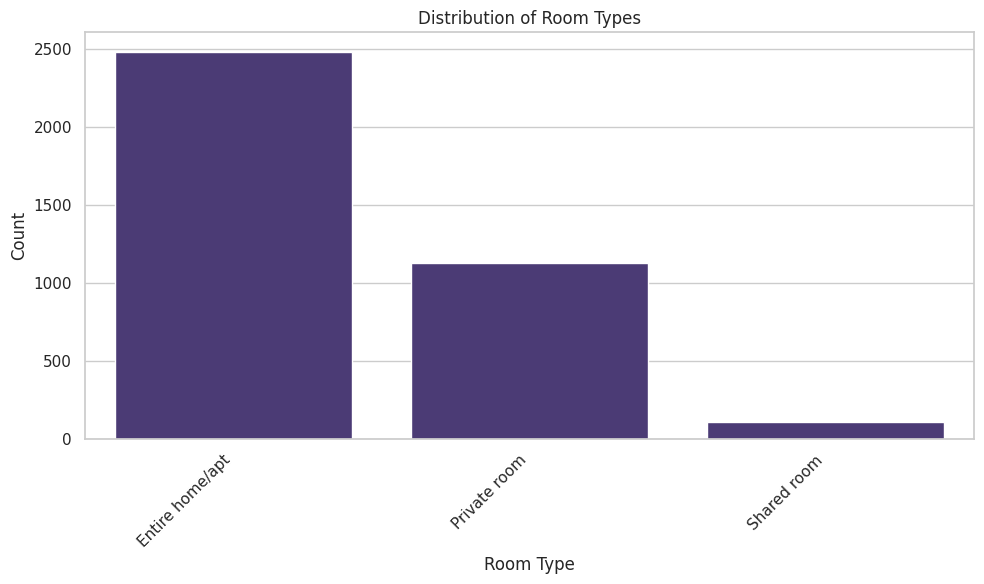

In [62]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='room_type', order = df['room_type'].value_counts().index)
plt.title('Distribution of Room Types')
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Col = neighbourhood

In [63]:
df['neighbourhood'].value_counts()

,count
neighbourhood,
unknown,392
Capitol Hill,347
Ballard,209
Belltown,198
Minor,186
...,...
South Beacon Hill,2
Pinehurst,2
Fairmount Park,1


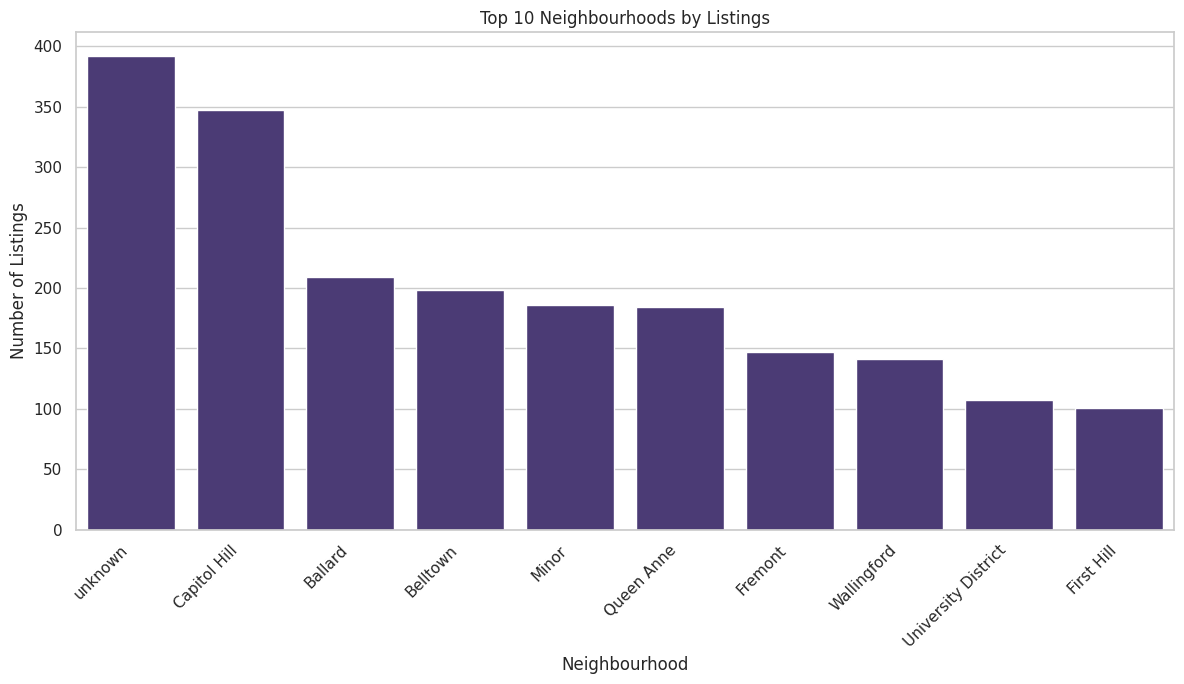

In [64]:
top_10_neighbourhoods = df['neighbourhood'].value_counts().nlargest(10).index

plt.figure(figsize=(12, 7))
sns.countplot(data=df, x='neighbourhood', order=top_10_neighbourhoods)
plt.title('Top 10 Neighbourhoods by Listings')
plt.xlabel('Neighbourhood')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Skewness of log-transformed price: 0.3915908943607115


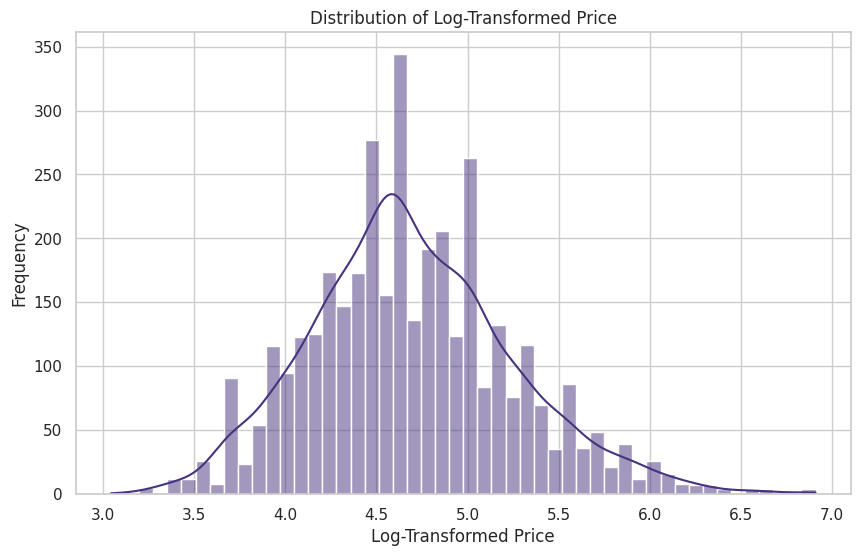

In [65]:
df['price_log'] = np.log1p(df['price'])
print(f"Skewness of log-transformed price: {df['price_log'].skew()}")

plt.figure(figsize=(10, 6))
sns.histplot(df['price_log'], bins=50, kde=True)
plt.title('Distribution of Log-Transformed Price')
plt.xlabel('Log-Transformed Price')
plt.ylabel('Frequency')
plt.show()

## Bivariate Analysis

accommodates vs price

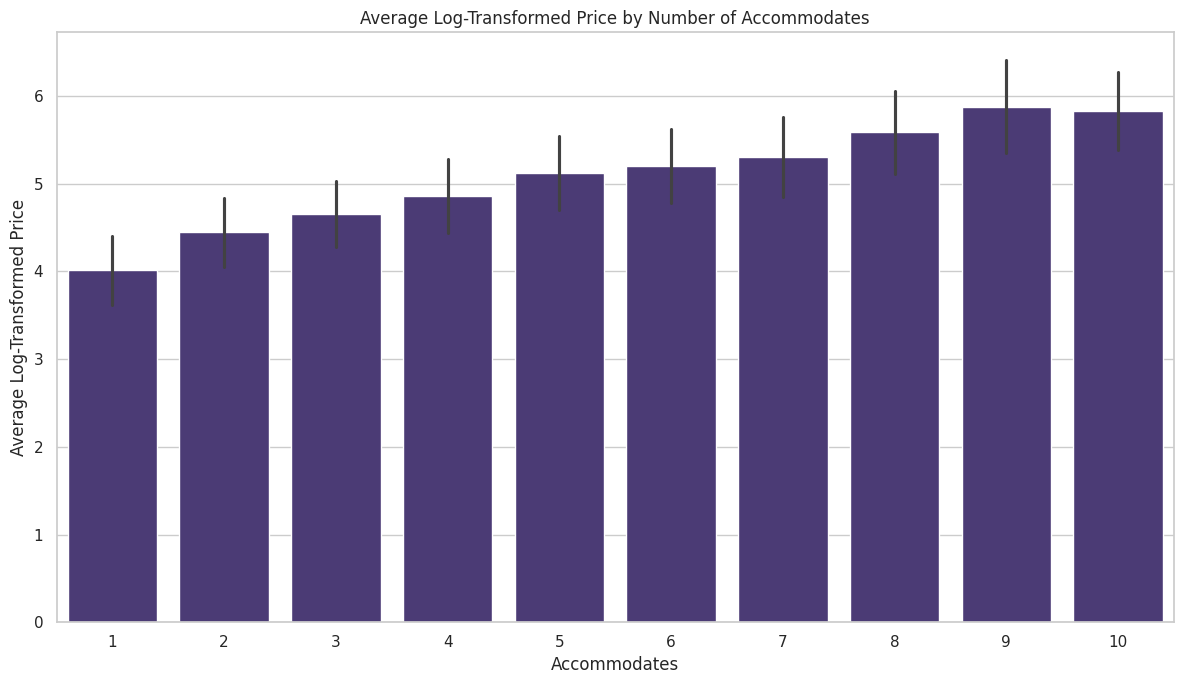

In [66]:
plt.figure(figsize=(12, 7))
sns.barplot(data=df, x='accommodates', y='price_log', errorbar='sd')
plt.title('Average Log-Transformed Price by Number of Accommodates')
plt.xlabel('Accommodates')
plt.ylabel('Average Log-Transformed Price')
plt.tight_layout()
plt.show()

There is a linear relationship between number of accommodates and the price

property_type vs Price

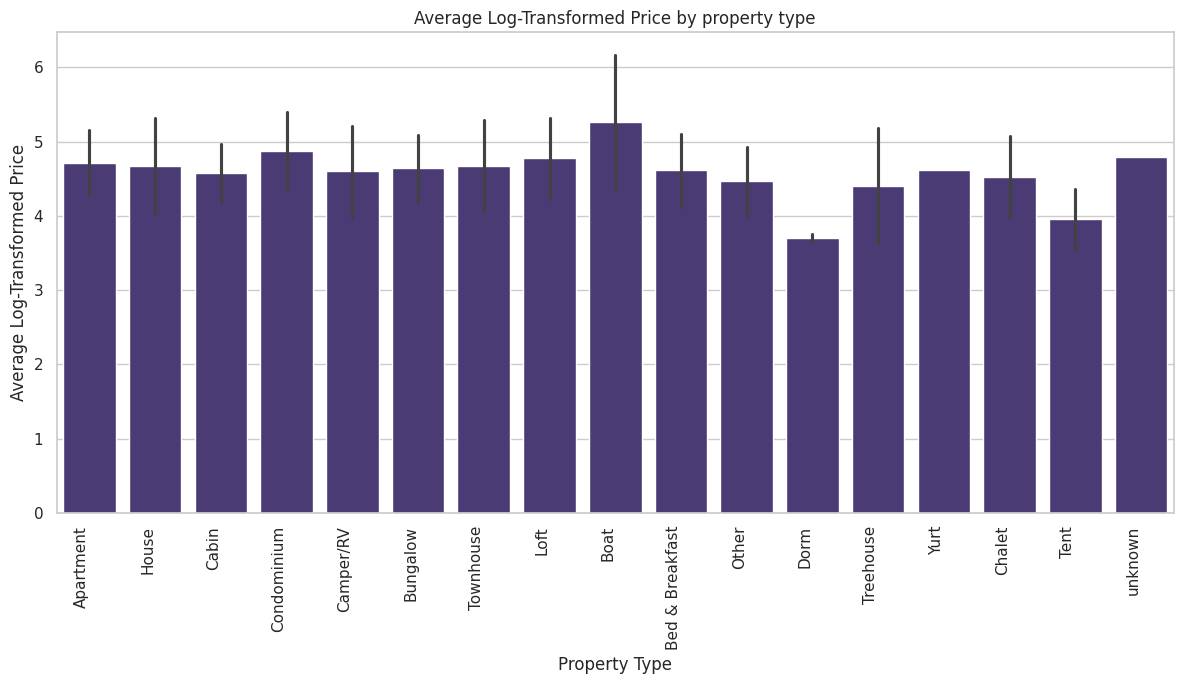

In [67]:
plt.figure(figsize=(12, 7))
sns.barplot(data=df, x='property_type', y='price_log', errorbar='sd')
plt.title('Average Log-Transformed Price by property type')
plt.xlabel('Property Type')
plt.ylabel('Average Log-Transformed Price')
plt.xticks(rotation=90, ha='right') # Rotate labels for better visibility
plt.tight_layout()
plt.show()

Price by room type

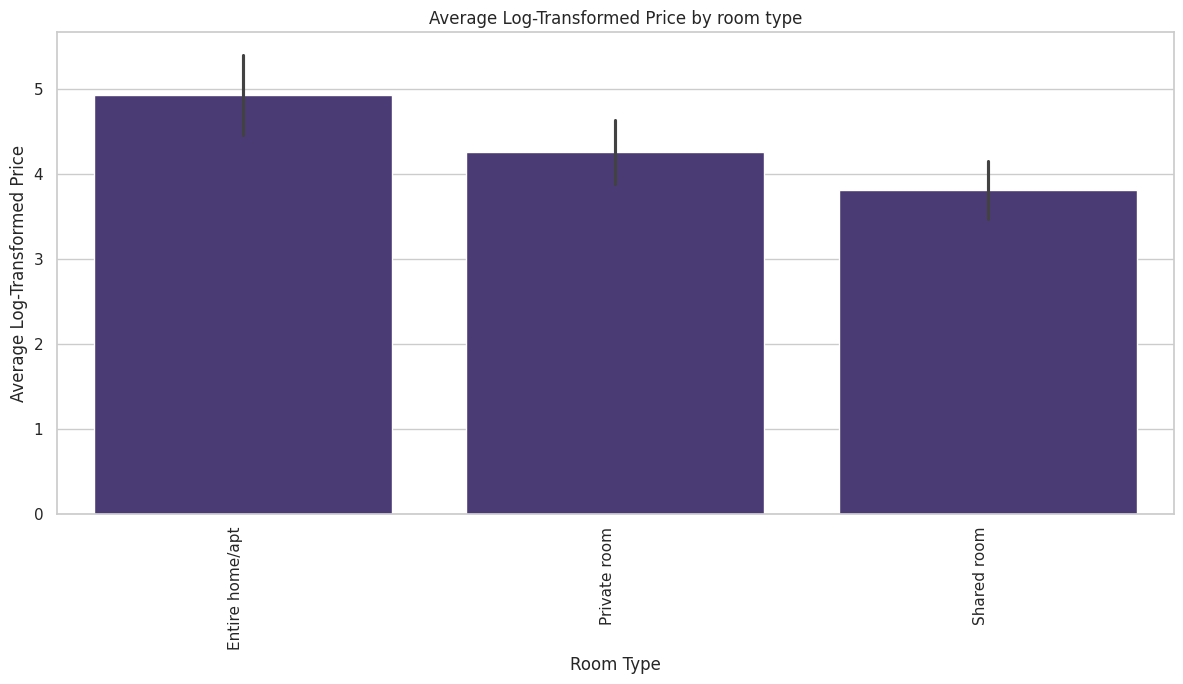

In [68]:
plt.figure(figsize=(12, 7))
sns.barplot(data=df, x='room_type', y='price_log', errorbar='sd')
plt.title('Average Log-Transformed Price by room type')
plt.xlabel('Room Type')
plt.ylabel('Average Log-Transformed Price')
plt.xticks(rotation=90, ha='right') # Rotate labels for better visibility
plt.tight_layout()
plt.show()

Price by neighborhood group

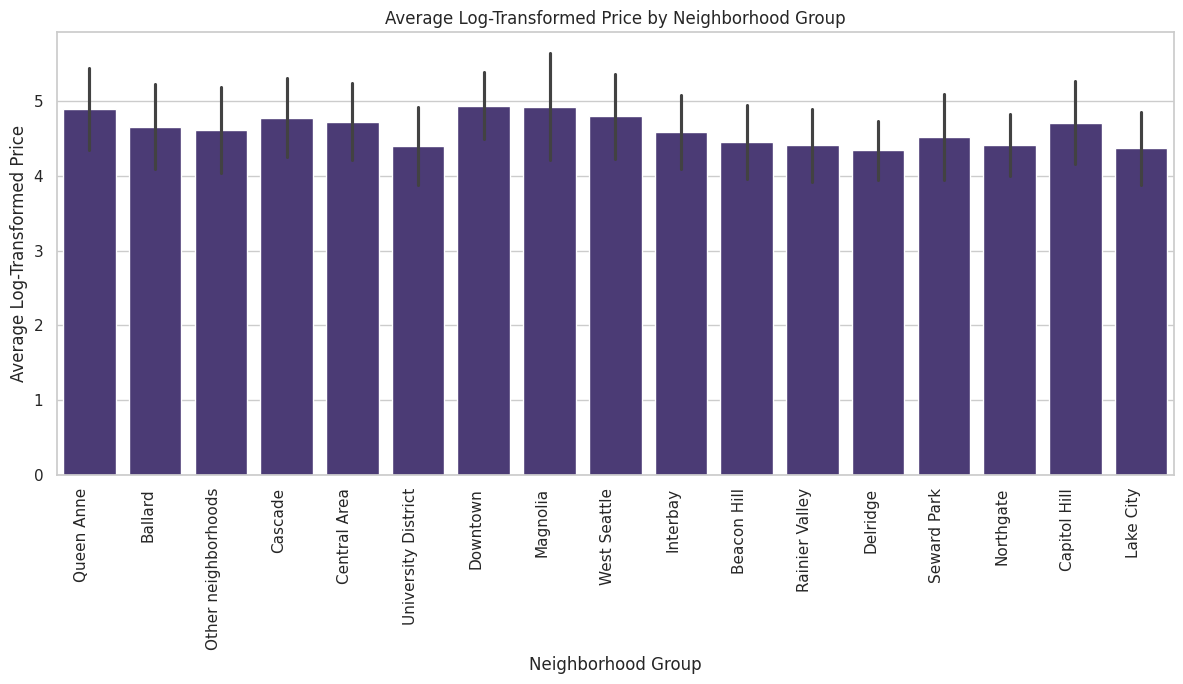

In [69]:
plt.figure(figsize=(12, 7))
sns.barplot(data=df, x='neighbourhood_group_cleansed', y='price_log', errorbar='sd')
plt.title('Average Log-Transformed Price by Neighborhood Group')
plt.xlabel('Neighborhood Group')
plt.ylabel('Average Log-Transformed Price')
plt.xticks(rotation=90, ha='right') # Rotate labels for better visibility
plt.tight_layout()
plt.show()

### Checking if providing good services other than materialistic ones add any value to rising prices

Relation between super host and price

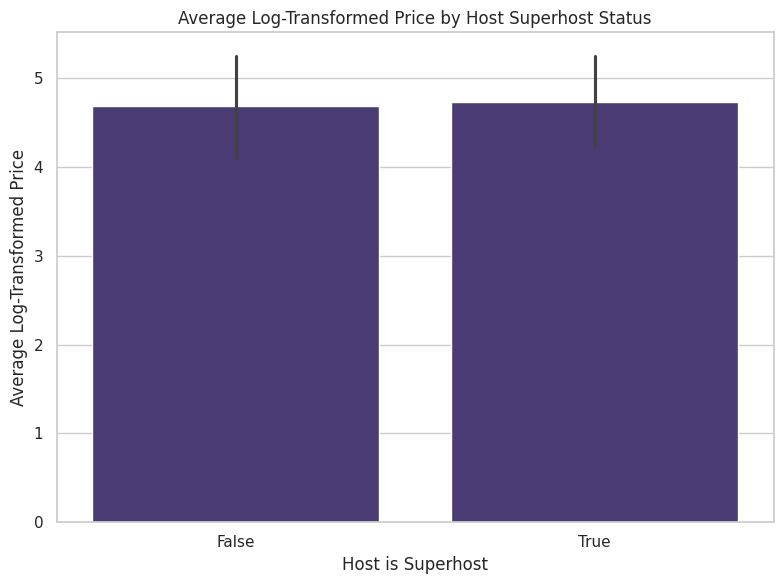

In [70]:
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x='host_is_superhost', y='price_log', errorbar='sd')
plt.title('Average Log-Transformed Price by Host Superhost Status')
plt.xlabel('Host is Superhost')
plt.ylabel('Average Log-Transformed Price')
plt.xticks(ticks=[0, 1], labels=['False', 'True'], rotation=0)
plt.tight_layout()
plt.show()

Being a superhost doesnt add much value to the price of the property

Relation between host_response_time and price

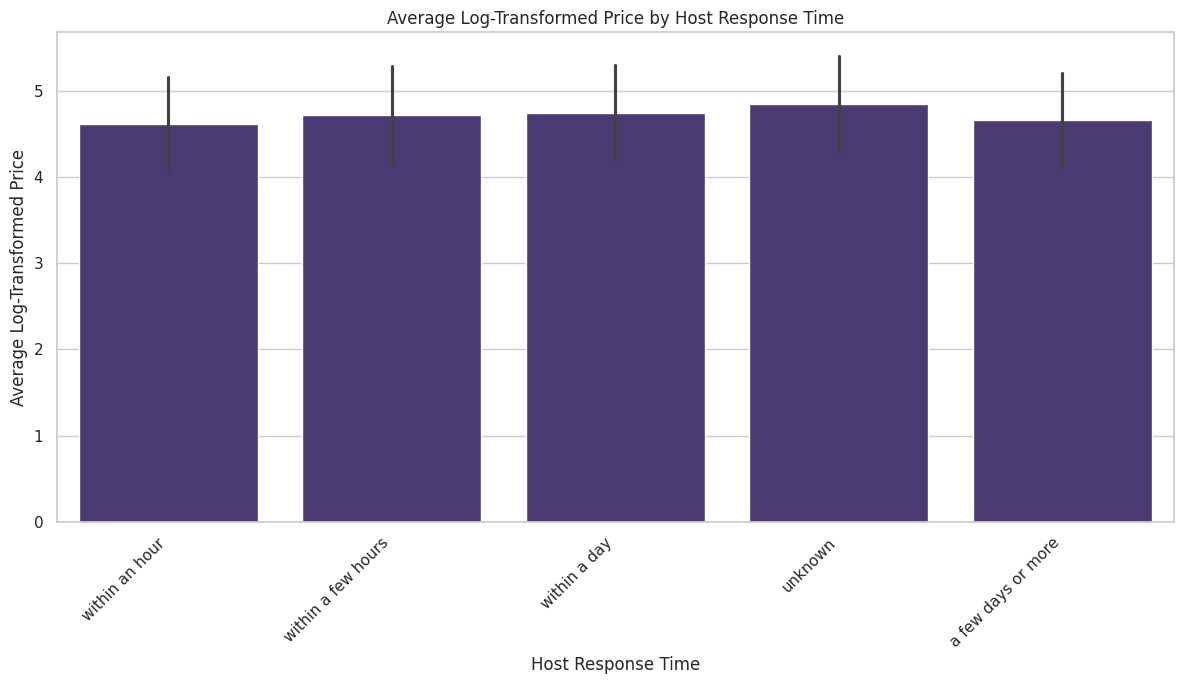

In [71]:
plt.figure(figsize=(12, 7))
sns.barplot(data=df, x='host_response_time', y='price_log', errorbar='sd', order=df['host_response_time'].value_counts().index)
plt.title('Average Log-Transformed Price by Host Response Time')
plt.xlabel('Host Response Time')
plt.ylabel('Average Log-Transformed Price')
plt.xticks(rotation=45, ha='right') # Rotate labels for better visibility
plt.tight_layout()
plt.show()

This also doesn't add much value to price

Relation between review_scores_value and price

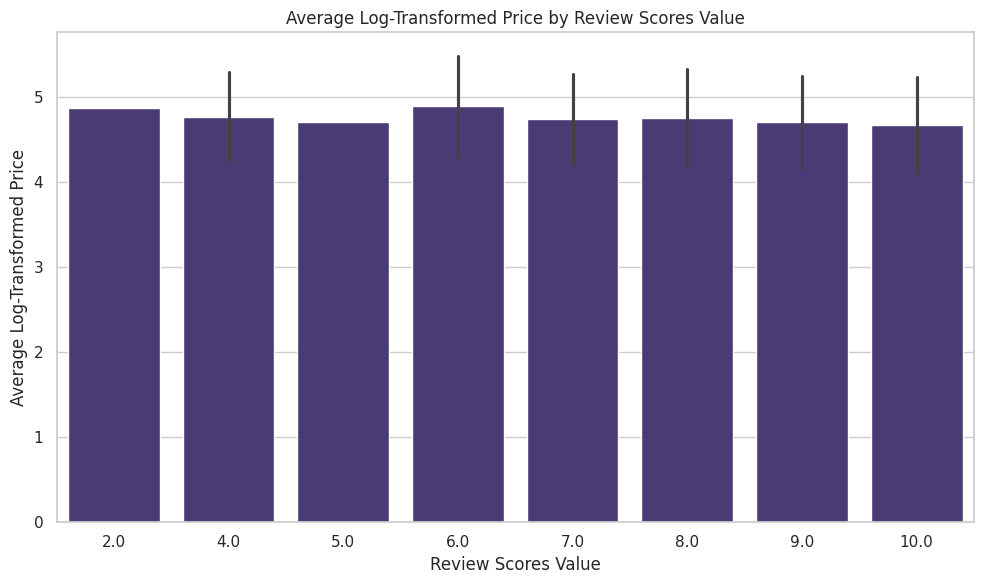

In [72]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='review_scores_value', y='price_log', errorbar='sd')
plt.title('Average Log-Transformed Price by Review Scores Value')
plt.xlabel('Review Scores Value')
plt.ylabel('Average Log-Transformed Price')
plt.tight_layout()
plt.show()

relation between instant_bookable and price

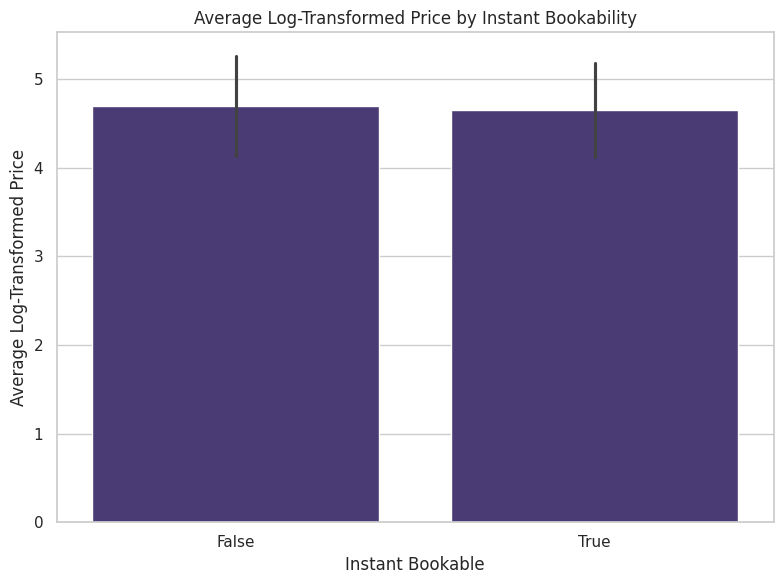

In [73]:
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x='instant_bookable', y='price_log', errorbar='sd')
plt.title('Average Log-Transformed Price by Instant Bookability')
plt.xlabel('Instant Bookable')
plt.ylabel('Average Log-Transformed Price')
plt.xticks(ticks=[0, 1], labels=['False', 'True'], rotation=0)
plt.tight_layout()
plt.show()

relation between cancellation_policy and price

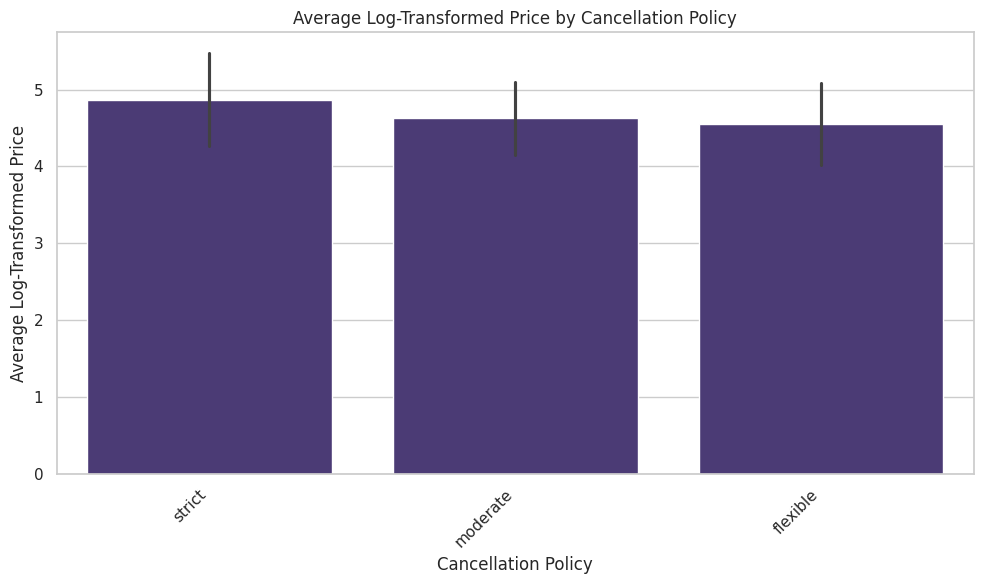

In [74]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='cancellation_policy', y='price_log', errorbar='sd', order=df['cancellation_policy'].value_counts().index)
plt.title('Average Log-Transformed Price by Cancellation Policy')
plt.xlabel('Cancellation Policy')
plt.ylabel('Average Log-Transformed Price')
plt.xticks(rotation=45, ha='right') # Rotate labels for better visibility
plt.tight_layout()
plt.show()

here's a summary of the relationships observed with the log-transformed price:

`Materialistic Features (showed a relationship with price):`

**Accommodates**: There appears to be a linear relationship, with the average log-transformed price generally increasing as the number of accommodates rises.

**Property Type**: Different property types showed varying average log-transformed prices, suggesting that the type of property influences pricing.

**Room Type**: The average log-transformed price differed significantly across room types (e.g., 'Entire home/apt' generally had higher prices than 'Private room' or 'Shared room').

**Neighborhood Group**: The average log-transformed price varied across different neighborhood groups, indicating that location is a factor in pricing.

`Service-Oriented Features (did not show a strong relationship with price):`

**Host is Superhost**: Being a superhost did not seem to add significant value to the average log-transformed price.

**Host Response Time**: The host's response time categories did not show a clear or substantial impact on the average log-transformed price.

**Review Scores Value**: There wasn't a strong linear relationship observed between review scores value and the average log-transformed price.

**Instant Bookable**: Whether a listing was instantly bookable or not did not significantly differentiate the average log-transformed price.

**Cancellation Policy**: Different cancellation policies did not seem to have a substantial impact on the average log-transformed price.

## Multicollinearity among size predictors

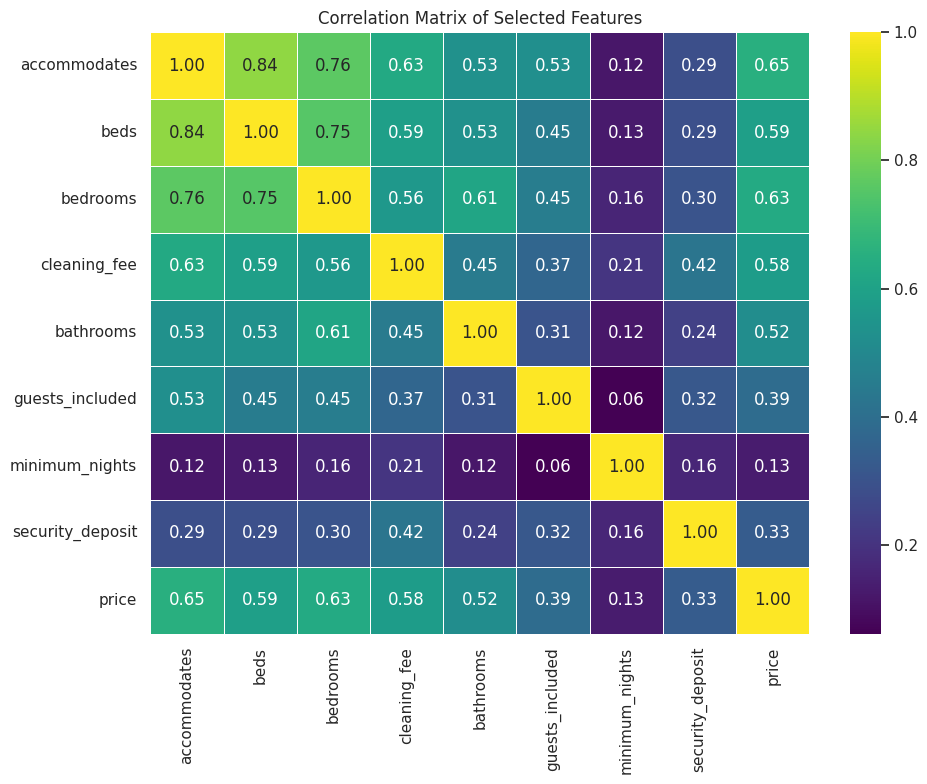

In [82]:
cols = ['accommodates', 'beds', 'bedrooms', 'cleaning_fee', 'bathrooms', 'guests_included', 'minimum_nights', 'security_deposit', 'price']
corr_matrix = df[cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Selected Features')
plt.tight_layout()
plt.show()

In [76]:
df['room_type'].value_counts()

,count
room_type,
Entire home/apt,2482
Private room,1131
Shared room,113


Room type and neighbourhood interaction

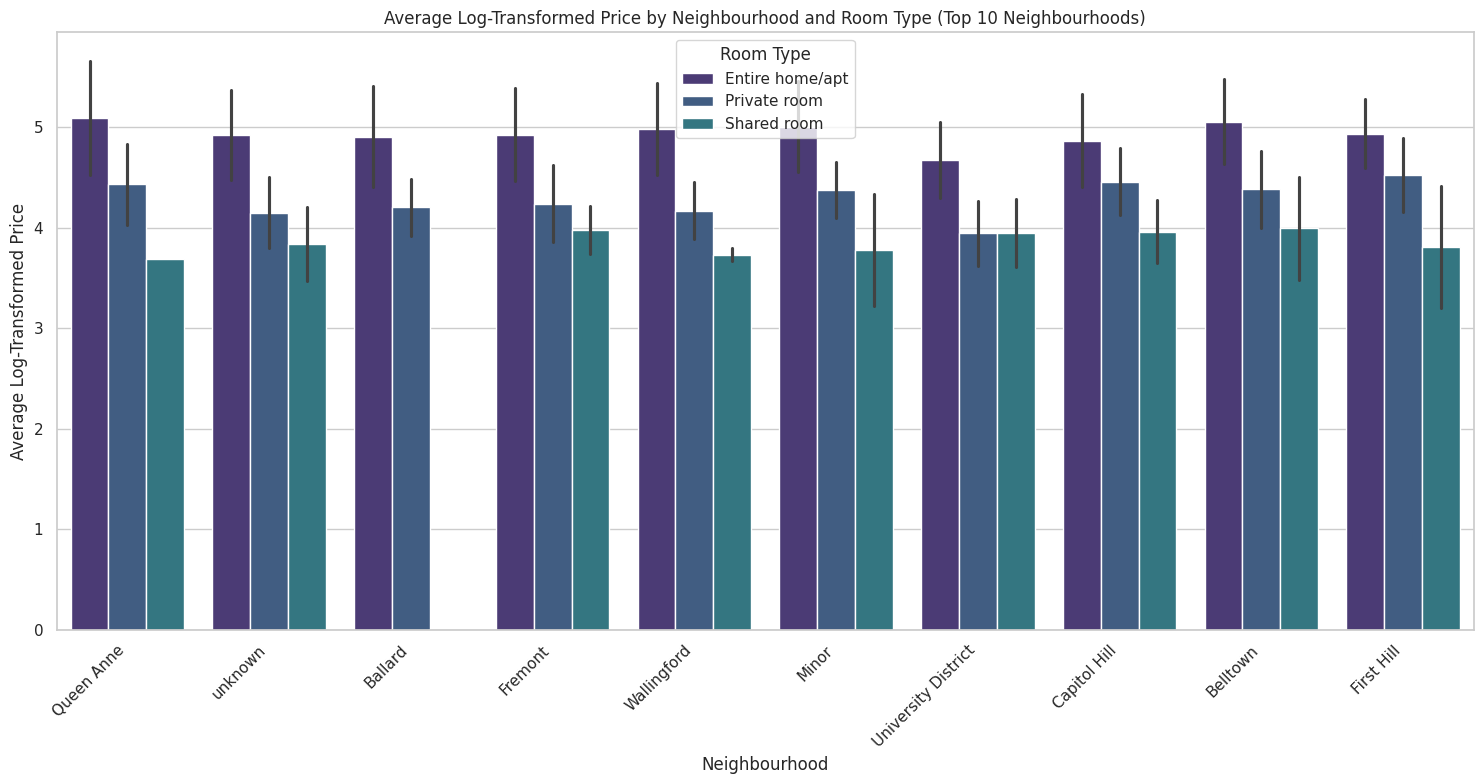

In [77]:
plt.figure(figsize=(15, 8))
sns.barplot(data=df[df['neighbourhood'].isin(top_10_neighbourhoods)],
            x='neighbourhood',
            y='price_log',
            hue='room_type',
            errorbar='sd')
plt.title('Average Log-Transformed Price by Neighbourhood and Room Type (Top 10 Neighbourhoods)')
plt.xlabel('Neighbourhood')
plt.ylabel('Average Log-Transformed Price')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Room Type')
plt.tight_layout()
plt.show()

It's clear that several materialistic features like accommodates, beds, bedrooms, cleaning_fee, bathrooms, and security_deposit show a positive correlation with price. It's also interesting to note that minimum_nights has a weaker correlation. My observation about property type and location influencing price, based on the previous bar charts, is also accurate. We will verify these findings using hypothesis testing

## Hypothesis Testing

`H0 hypothesis`: There is no statitically significant difference between room types and price.

`H1 hypothesis`: There is statitically significant difference between room types and price.

In [85]:
from scipy.stats import f_oneway

# Prepare data for ANOVA test on room_type and price_log
room_types = df['room_type'].unique()
price_groups = [df['price'][df['room_type'] == rt] for rt in room_types]

# Perform ANOVA test
f_statistic, p_value = f_oneway(*price_groups)

print(f"ANOVA F-statistic for Room Type: {f_statistic:.2f}")
print(f"ANOVA P-value for Room Type: {p_value:.3f}")

if p_value < 0.05:
    print("Conclusion: We reject the null hypothesis. There is a statistically significant difference in average price across different room types.")
else:
    print("Conclusion: We fail to reject the null hypothesis. There is no statistically significant difference in average  price across different room types.")

ANOVA F-statistic for Room Type: 442.83
ANOVA P-value for Room Type: 0.000
Conclusion: We reject the null hypothesis. There is a statistically significant difference in average price across different room types.


`H0 hypothesis`: There is no statitically significant difference between property types and price.

`H1 hypothesis`: There is statitically significant difference between property types and price.

In [88]:
from scipy.stats import f_oneway

# Prepare data for ANOVA test on property_type and price_log
property_types = df['property_type'].unique()
price_groups_property = [df['price_log'][df['property_type'] == pt] for pt in property_types]

# Perform ANOVA test
f_statistic_property, p_value_property = f_oneway(*price_groups_property)

print(f"ANOVA F-statistic for Property Type: {f_statistic_property:.2f}")
print(f"ANOVA P-value for Property Type: {p_value_property:.3f}")

if p_value_property < 0.05:
    print("Conclusion: We reject the null hypothesis. There is a statistically significant difference in average price across different property types.")
else:
    print("Conclusion: We fail to reject the null hypothesis. There is no statistically significant difference in average  price across different property types.")

ANOVA F-statistic for Property Type: 3.00
ANOVA P-value for Property Type: 0.000
Conclusion: We reject the null hypothesis. There is a statistically significant difference in average price across different property types.


`H0 hypothesis`: There is no statitically significant difference between location and price.

`H1 hypothesis`: There is statitically significant difference between location and price.

In [90]:
from scipy.stats import f_oneway

# Prepare data for ANOVA test on neighbourhood_group_cleansed and price_log
neighbourhood_groups = df['neighbourhood_group_cleansed'].unique()
price_groups_neighbourhood = [df['price_log'][df['neighbourhood_group_cleansed'] == ng] for ng in neighbourhood_groups]

# Perform ANOVA test
f_statistic_neighbourhood, p_value_neighbourhood = f_oneway(*price_groups_neighbourhood)

print(f"ANOVA F-statistic for Neighbourhood Group: {f_statistic_neighbourhood:.2f}")
print(f"ANOVA P-value for Neighbourhood Group: {p_value_neighbourhood:.3f}")

if p_value_neighbourhood < 0.05:
    print("Conclusion: We reject the null hypothesis. There is a statistically significant difference in average price across different location.")
else:
    print("Conclusion: We fail to reject the null hypothesis. There is no statistically significant difference in average price across different location.")

ANOVA F-statistic for Neighbourhood Group: 23.58
ANOVA P-value for Neighbourhood Group: 0.000
Conclusion: We reject the null hypothesis. There is a statistically significant difference in average price across different location.


`H0 hypothesis`: There is no statitically significant difference between host is superhost and price.

`H1 hypothesis`: There is statitically significant difference between host is superhost and price.

In [93]:
from scipy.stats import ttest_ind

# Separate price_log for superhosts and non-superhosts
superhost_prices = df[df['host_is_superhost'] == True]['price_log']
non_superhost_prices = df[df['host_is_superhost'] == False]['price_log']

# Perform independent samples t-test
t_statistic, p_value_superhost = ttest_ind(superhost_prices, non_superhost_prices)

print(f"\nT-statistic for Superhost Status: {t_statistic:.2f}")
print(f"P-value for Superhost Status: {p_value_superhost:.3f}")

if p_value_superhost < 0.05:
    print("Conclusion: We reject the null hypothesis. There is a statistically significant difference in average log-transformed price between superhosts and non-superhosts.")
else:
    print("Conclusion: We fail to reject the null hypothesis. There is no statistically significant difference in average log-transformed price between superhosts and non-superhosts.")


T-statistic for Superhost Status: 2.37
P-value for Superhost Status: 0.018
Conclusion: We reject the null hypothesis. There is a statistically significant difference in average log-transformed price between superhosts and non-superhosts.


During the EDA, when we looked at the bar plot for 'Superhost Status' and price_log, the average prices for superhosts and non-superhosts appeared quite similar. Visually, the difference seemed small, leading to the initial conclusion that being a superhost 'doesn't add much value to the price.'

However, the independent samples t-test (hypothesis testing) tells us that this seemingly small difference is, in fact, statistically significant (p-value = 0.018, which is less than 0.05). This means that the observed difference in average log-transformed prices between superhosts and non-superhosts is unlikely to have occurred by random chance. While the magnitude of the difference might not be huge from a practical standpoint, the test confirms that there is a real, albeit potentially small, effect.

So, the hypothesis test provides a more rigorous, quantitative confirmation that superhost status does have a statistically discernible impact on price, even if that impact isn't dramatically visible on a basic bar chart.

We will dive depper into this using Turkey's hsd test

Let's test for other services to come into conclusion

In [94]:
from scipy.stats import f_oneway

# Prepare data for ANOVA test on cancellation_policy and price_log
cancellation_policies = df['cancellation_policy'].unique()
price_groups_cancellation = [df['price_log'][df['cancellation_policy'] == cp] for cp in cancellation_policies]

# Perform ANOVA test
f_statistic_cancellation, p_value_cancellation = f_oneway(*price_groups_cancellation)

print(f"\nANOVA F-statistic for Cancellation Policy: {f_statistic_cancellation:.2f}")
print(f"ANOVA P-value for Cancellation Policy: {p_value_cancellation:.3f}")

if p_value_cancellation < 0.05:
    print("Conclusion: We reject the null hypothesis. There is a statistically significant difference in average log-transformed price across different cancellation policies.")
else:
    print("Conclusion: We fail to reject the null hypothesis. There is no statistically significant difference in average log-transformed price across different cancellation policies.")


ANOVA F-statistic for Cancellation Policy: 119.77
ANOVA P-value for Cancellation Policy: 0.000
Conclusion: We reject the null hypothesis. There is a statistically significant difference in average log-transformed price across different cancellation policies.


Since the ANOVA test showed a statistically significant difference and the plot above showed a very small to no difference wrt price, we'll perform a Tukey's HSD post-hoc test to verify how specific cancellation policies differ from each other.

Tukey's HSD Post-Hoc Test for Cancellation Policy:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1   group2  meandiff p-adj  lower  upper  reject
------------------------------------------------------
flexible moderate   0.0741 0.0028 0.0214 0.1268   True
flexible   strict   0.3166    0.0 0.2655 0.3677   True
moderate   strict   0.2425    0.0 0.1925 0.2925   True
------------------------------------------------------


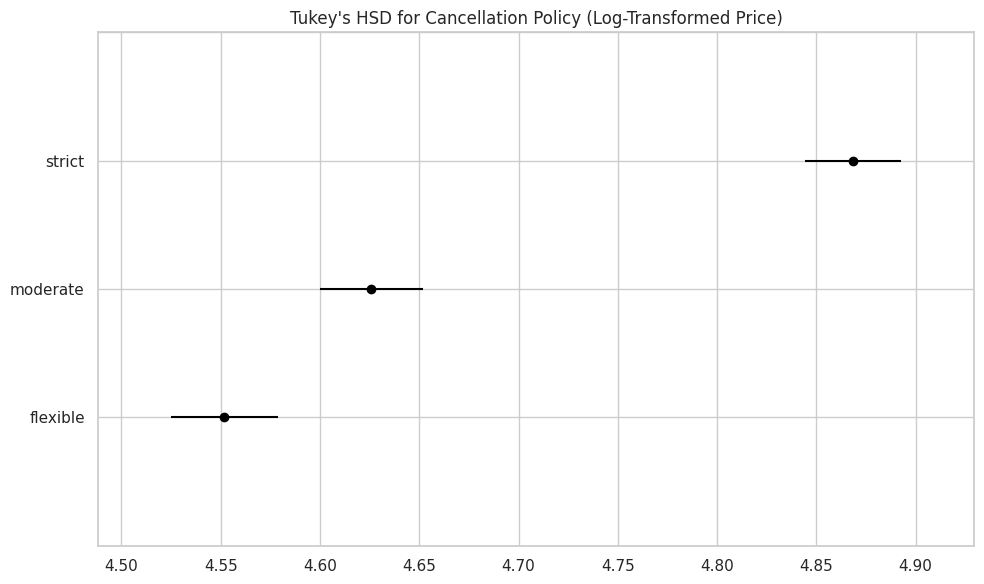

In [95]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey's HSD post-hoc test for Cancellation Policy
tukey_cancellation_policy = pairwise_tukeyhsd(endog=df['price_log'], groups=df['cancellation_policy'], alpha=0.05)

print("Tukey's HSD Post-Hoc Test for Cancellation Policy:")
print(tukey_cancellation_policy)

# Visualize the results
tukey_cancellation_policy.plot_simultaneous()
plt.title("Tukey's HSD for Cancellation Policy (Log-Transformed Price)")
plt.tight_layout()
plt.show()

The Tukey's HSD post-hoc test indeed shows that all cancellation policy groups have statistically significant differences in their average log-transformed prices. Specifically:

`Strict cancellation` policies are associated with the highest average prices.

`Moderate cancellation` policies have higher average prices than flexible policies, but lower than strict policies.

`Flexible cancellation` policies are associated with the lowest average prices.

Tukey's HSD Post-Hoc Test for Room Type:
         Multiple Comparison of Means - Tukey HSD, FWER=0.05          
     group1        group2     meandiff p-adj   lower    upper   reject
----------------------------------------------------------------------
Entire home/apt Private room   -81.031    0.0 -87.8782 -74.1838   True
Entire home/apt  Shared room -109.0404    0.0 -127.399 -90.6818   True
   Private room  Shared room  -28.0094 0.0014 -46.8395  -9.1794   True
----------------------------------------------------------------------


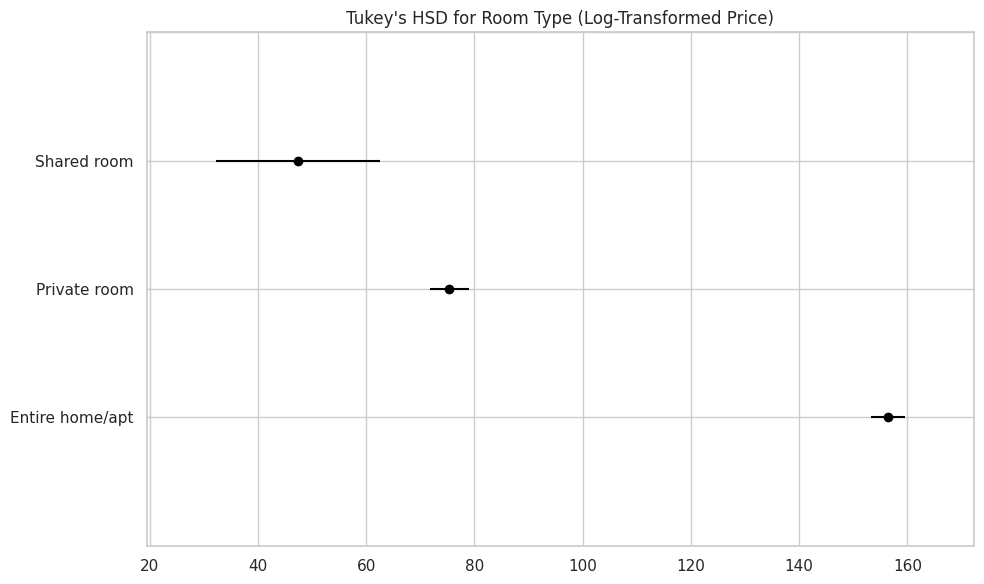

In [92]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey's HSD post-hoc test for Room Type
tukey_room_type = pairwise_tukeyhsd(endog=df['price'], groups=df['room_type'], alpha=0.05)

print("Tukey's HSD Post-Hoc Test for Room Type:")
print(tukey_room_type)

# Visualize the results
tukey_room_type.plot_simultaneous()
plt.title("Tukey's HSD for Room Type (Log-Transformed Price)")
plt.tight_layout()
plt.show()

`Entire home/apt` listings are significantly more expensive than `Private room` listings, which in turn are significantly more expensive than `Shared room` listings. The plot also visually represents these differences and their confidence intervals, where non-overlapping intervals indicate significant differences.

Factors such as `accommodates`, `room types`, `property types`, `location` has a direct correlation with `price` later I verified this using hypothesis testing. Whereas factors such as `host is superhost`, `cancellation policy`, `review scores` showed little to no correlation with `price` visually while later verifying these results using hypothesis testing we came to know that they also have a significant correlation with `price`.